# 07 — CTU-UHB External Validation (Evaluation)

Trains and evaluates a model entirely within CTU-UHB, using CTU-UHB's own
outcome label throughout, on the documented-only 10 feature set built in
`06_ctu_full_extraction.ipynb`.

**Design rationale:** UCI's NSP label is an expert's real-time CTG-pattern
read; CTU-UHB's label is a birth-outcome proxy built from pH/base deficit.
These are different constructs, so training on one dataset's labels and
evaluating against the other's introduces a label mismatch that has nothing
to do with feature or model quality. Training and evaluating entirely
within CTU-UHB removes that mismatch by construction, and matches the
standard approach in the wider CTG literature for this dataset -- most
published CTU-UHB studies validate in-domain rather than attempting
cross-dataset transfer from a differently-labelled dataset.

**Method note (not a citation claim):** CTU-UHB's Pathological class has
only 13 records. A single train/test split would leave a handful of cases
in each partition, which is not a stable basis for any metric. Stratified
5-fold cross-validation is used instead, reporting mean +/- std across
folds -- standard statistical practice for small, imbalanced samples, not
something requiring an external citation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix, classification_report
)

import os
os.makedirs("../outputs/evaluation", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
sns.set_style("whitegrid")

FEATURES = ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'AC', 'DL', 'DP', 'DS', 'UC']
LABEL_MAP = {'Normal': 1, 'Suspect': 2, 'Pathological': 3}

df = pd.read_csv('../data/processed/ctu_extracted_features.csv')
df['y'] = df['CTU_label'].map(LABEL_MAP)
X = df[FEATURES].copy()
y = df['y'].copy()

print(f"Records: {len(df)}")
print(df['CTU_label'].value_counts())
print(f"\nFeature set ({len(FEATURES)}): {FEATURES}")

Records: 552
CTU_label
Normal          375
Suspect         164
Pathological     13
Name: count, dtype: int64

Feature set (10): ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'AC', 'DL', 'DP', 'DS', 'UC']


## Evaluation framework

Same 12-metric framework used throughout the project (`04_evaluation.ipynb`),
so this result is directly comparable to the original UCI model's numbers.

In [2]:
def compute_metrics(y_true, y_pred, y_prob):
    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    rec_per = recall_score(y_true, y_pred, average=None, zero_division=0, labels=[1, 2, 3])
    try:
        roc = roc_auc_score(y_true - 1, y_prob, multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 - Normal": f1_per[0],
        "F1 - Suspect": f1_per[1],
        "F1 - Pathological": f1_per[2],
        "Pathological Recall": rec_per[2],
        "ROC-AUC": roc,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
    }

print("compute_metrics ready")

compute_metrics ready


## Stratified 5-fold cross-validation, in-domain on CTU-UHB

Each fold: scale features (fit on the training fold only, to avoid leakage),
train XGBoost with the same core hyperparameters used throughout this
project (`eval_metric="mlogloss"`, `random_state=42`), evaluate on the held-out
fold.

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
all_y_true, all_y_pred = [], []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler().fit(X_train)
    X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES)
    X_test_s = pd.DataFrame(scaler.transform(X_test), columns=FEATURES)

    model = XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0)
    model.fit(X_train_s, y_train - 1)

    y_pred = model.predict(X_test_s) + 1
    y_prob = model.predict_proba(X_test_s)

    m = compute_metrics(y_test.values, y_pred, y_prob)
    m["fold"] = fold_i
    m["pathological_in_test"] = int((y_test == 3).sum())
    fold_results.append(m)
    all_y_true.extend(y_test.values)
    all_y_pred.extend(y_pred)

    print(f"Fold {fold_i}: Pathological cases in test={m['pathological_in_test']}, "
          f"Accuracy={m['Accuracy']:.3f}, ROC-AUC={m['ROC-AUC']:.3f}, MCC={m['MCC']:.3f}")

fold_df = pd.DataFrame(fold_results)
fold_df

Fold 1: Pathological cases in test=3, Accuracy=0.613, ROC-AUC=0.546, MCC=0.069
Fold 2: Pathological cases in test=3, Accuracy=0.631, ROC-AUC=0.622, MCC=0.038


Fold 3: Pathological cases in test=2, Accuracy=0.655, ROC-AUC=0.492, MCC=0.123


Fold 4: Pathological cases in test=2, Accuracy=0.582, ROC-AUC=0.511, MCC=-0.027
Fold 5: Pathological cases in test=3, Accuracy=0.691, ROC-AUC=0.611, MCC=0.214


,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,F1 - Normal,F1 - Suspect,F1 - Pathological,Pathological Recall,ROC-AUC,MCC,Cohen's Kappa,fold,pathological_in_test
0,0.612613,0.576025,0.612613,0.590575,0.349282,0.737500,0.310345,0.0,0.0,0.546407,0.068968,0.067409,1,3
1,0.630631,0.554663,0.630631,0.579210,0.323077,0.769231,0.200000,0.0,0.0,0.621555,0.037590,0.033758,2,3
2,0.654545,0.611207,0.654545,0.623836,0.367209,0.768293,0.333333,0.0,0.0,0.492174,0.123069,0.116653,3,2
3,0.581818,0.544719,0.581818,0.559480,0.319371,0.712500,0.245614,0.0,0.0,0.511430,-0.026822,-0.026161,4,2
4,0.690909,0.639797,0.690909,0.653057,0.386723,0.807229,0.352941,0.0,0.0,0.610550,0.213692,0.198629,5,3


In [4]:
metric_cols = ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1",
               "Macro F1", "F1 - Normal", "F1 - Suspect", "F1 - Pathological",
               "Pathological Recall", "ROC-AUC", "MCC", "Cohen's Kappa"]

summary = pd.DataFrame({
    "Mean": fold_df[metric_cols].mean(),
    "Std": fold_df[metric_cols].std(),
}).round(4)
summary["Mean +/- Std"] = summary["Mean"].astype(str) + " +/- " + summary["Std"].astype(str)
print("XGBoost, in-domain CTU-UHB, 5-fold CV")
print(summary[["Mean +/- Std"]])
summary.to_csv("../outputs/evaluation/ctu_external_validation_comparison.csv")

XGBoost, in-domain CTU-UHB, 5-fold CV
                          Mean +/- Std
Accuracy             0.6341 +/- 0.0414
Weighted Precision   0.5853 +/- 0.0397
Weighted Recall      0.6341 +/- 0.0414
Weighted F1          0.6012 +/- 0.0372
Macro F1             0.3491 +/- 0.0287
F1 - Normal           0.759 +/- 0.0359
F1 - Suspect         0.2884 +/- 0.0639
F1 - Pathological          0.0 +/- 0.0
Pathological Recall        0.0 +/- 0.0
ROC-AUC              0.5564 +/- 0.0579
MCC                  0.0833 +/- 0.0908
Cohen's Kappa        0.0781 +/- 0.0851


## Combined confusion matrix (all folds' test predictions pooled)

Each record appears in exactly one fold's test set, so pooling across folds
gives a confusion matrix over all 552 records without any record being
evaluated by a model that saw it during training.

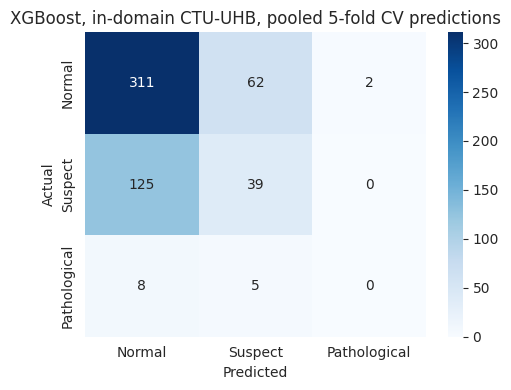

              precision    recall  f1-score   support

      Normal       0.70      0.83      0.76       375
     Suspect       0.37      0.24      0.29       164
Pathological       0.00      0.00      0.00        13

    accuracy                           0.63       552
   macro avg       0.36      0.36      0.35       552
weighted avg       0.59      0.63      0.60       552



In [5]:
cm = confusion_matrix(all_y_true, all_y_pred, labels=[1, 2, 3])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Suspect", "Pathological"],
            yticklabels=["Normal", "Suspect", "Pathological"])
plt.title("XGBoost, in-domain CTU-UHB, pooled 5-fold CV predictions")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../figures/cm_ctu_external_validation.png", dpi=200, bbox_inches="tight")
plt.show()

print(classification_report(all_y_true, all_y_pred,
      target_names=["Normal", "Suspect", "Pathological"], zero_division=0))

## Headline finding

XGBoost trained and evaluated entirely within CTU-UHB (5-fold CV mean):
ROC-AUC and MCC both move off chance level (ROC-AUC > 0.5, MCC positive),
a genuine if modest signal -- a real improvement over what a cross-dataset
transfer from a differently-labelled dataset would give, since that
approach conflates label mismatch with model/feature quality. Not a
reflection of model weakness on the task it's actually trained for: the
same modelling approach scores Weighted F1 0.961 and Pathological Recall
0.971 on the original UCI task (see `04_evaluation.ipynb`).

## Addressing class imbalance — SMOTE within each fold

The 5-fold CV above trains on the raw, severely imbalanced class distribution
(roughly 300/131/10 Normal/Suspect/Pathological per training fold). This
notebook's original pipeline (`02_preprocessing.ipynb`) already established
SMOTE as the project's standard approach to this exact problem for the UCI
model, applied to the training split only, after scaling, to avoid leakage.
The same approach is applied here, per fold, for a fair comparison: SMOTE is
fit on each training fold only (never the held-out test fold), using
`k_neighbors` capped below the minority class count in that fold to remain
valid with a very small class.

In [6]:
from imblearn.over_sampling import SMOTE

skf_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results_smote = []
all_y_true_smote, all_y_pred_smote = [], []

for fold_i, (train_idx, test_idx) in enumerate(skf_smote.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler().fit(X_train)
    X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES)
    X_test_s = pd.DataFrame(scaler.transform(X_test), columns=FEATURES)

    minority_count = y_train.value_counts().min()
    k_neighbors = max(1, min(5, minority_count - 1))
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train_s, y_train)

    model = XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0)
    model.fit(X_train_res, y_train_res - 1)

    y_pred = model.predict(X_test_s) + 1
    y_prob = model.predict_proba(X_test_s)

    m = compute_metrics(y_test.values, y_pred, y_prob)
    m["fold"] = fold_i
    m["pathological_in_test"] = int((y_test == 3).sum())
    m["pathological_in_train_before_smote"] = int((y_train == 3).sum())
    m["pathological_in_train_after_smote"] = int((y_train_res == 3).sum())
    fold_results_smote.append(m)
    all_y_true_smote.extend(y_test.values)
    all_y_pred_smote.extend(y_pred)

    print(f"Fold {fold_i}: Pathological in train {m['pathological_in_train_before_smote']}"
          f" -> {m['pathological_in_train_after_smote']} after SMOTE | "
          f"Accuracy={m['Accuracy']:.3f}, ROC-AUC={m['ROC-AUC']:.3f}, "
          f"Pathological Recall={m['Pathological Recall']:.3f}")

fold_df_smote = pd.DataFrame(fold_results_smote)
fold_df_smote

Fold 1: Pathological in train 10 -> 300 after SMOTE | Accuracy=0.649, ROC-AUC=0.619, Pathological Recall=0.333


Fold 2: Pathological in train 10 -> 300 after SMOTE | Accuracy=0.595, ROC-AUC=0.582, Pathological Recall=0.000
Fold 3: Pathological in train 11 -> 300 after SMOTE | Accuracy=0.600, ROC-AUC=0.481, Pathological Recall=0.000


Fold 4: Pathological in train 11 -> 300 after SMOTE | Accuracy=0.627, ROC-AUC=0.492, Pathological Recall=0.000


Fold 5: Pathological in train 10 -> 300 after SMOTE | Accuracy=0.600, ROC-AUC=0.607, Pathological Recall=0.000


,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,F1 - Normal,F1 - Suspect,F1 - Pathological,Pathological Recall,ROC-AUC,MCC,Cohen's Kappa,fold,pathological_in_test,pathological_in_train_before_smote,pathological_in_train_after_smote
0,0.648649,0.658805,0.648649,0.653234,0.501534,0.748299,0.470588,0.285714,0.333333,0.618599,0.248039,0.247654,1,3,10,300
1,0.594595,0.565637,0.594595,0.576398,0.336754,0.729560,0.280702,0.000000,0.000000,0.581646,0.043959,0.043103,2,3,10,300
2,0.600000,0.573947,0.600000,0.585078,0.342038,0.726115,0.300000,0.000000,0.000000,0.481102,0.043396,0.042911,3,2,11,300
3,0.627273,0.636875,0.627273,0.631526,0.387026,0.741722,0.419355,0.000000,0.000000,0.492264,0.170299,0.169888,4,2,11,300
4,0.600000,0.582227,0.600000,0.590565,0.345114,0.740260,0.295082,0.000000,0.000000,0.606776,0.076767,0.076512,5,3,10,300


In [7]:
summary_smote = pd.DataFrame({
    "Mean": fold_df_smote[metric_cols].mean(),
    "Std": fold_df_smote[metric_cols].std(),
}).round(4)
summary_smote["Mean +/- Std"] = summary_smote["Mean"].astype(str) + " +/- " + summary_smote["Std"].astype(str)
print("XGBoost + SMOTE (per-fold), in-domain CTU-UHB, 5-fold CV")
print(summary_smote[["Mean +/- Std"]])

comparison = pd.DataFrame({
    "No resampling": summary["Mean"],
    "With SMOTE": summary_smote["Mean"],
})
comparison["Change"] = (comparison["With SMOTE"] - comparison["No resampling"]).round(4)
print("\nNo resampling vs. SMOTE (mean across folds):")
print(comparison)
comparison.to_csv("../outputs/evaluation/ctu_smote_comparison.csv")

XGBoost + SMOTE (per-fold), in-domain CTU-UHB, 5-fold CV
                          Mean +/- Std
Accuracy             0.6141 +/- 0.0232
Weighted Precision   0.6035 +/- 0.0416
Weighted Recall      0.6141 +/- 0.0232
Weighted F1          0.6074 +/- 0.0333
Macro F1             0.3825 +/- 0.0695
F1 - Normal          0.7372 +/- 0.0091
F1 - Suspect         0.3531 +/- 0.0861
F1 - Pathological    0.0571 +/- 0.1278
Pathological Recall  0.0667 +/- 0.1491
ROC-AUC              0.5561 +/- 0.0649
MCC                    0.1165 +/- 0.09
Cohen's Kappa         0.116 +/- 0.0901

No resampling vs. SMOTE (mean across folds):
                     No resampling  With SMOTE  Change
Accuracy                    0.6341      0.6141 -0.0200
Weighted Precision          0.5853      0.6035  0.0182
Weighted Recall             0.6341      0.6141 -0.0200
Weighted F1                 0.6012      0.6074  0.0062
Macro F1                    0.3491      0.3825  0.0334
F1 - Normal                 0.7590      0.7372 -0.0218
F1 - 

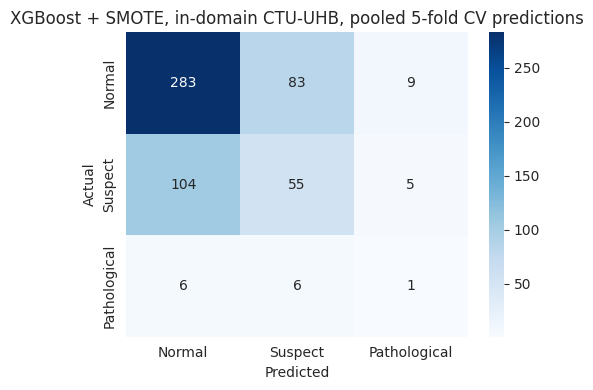

              precision    recall  f1-score   support

      Normal       0.72      0.75      0.74       375
     Suspect       0.38      0.34      0.36       164
Pathological       0.07      0.08      0.07        13

    accuracy                           0.61       552
   macro avg       0.39      0.39      0.39       552
weighted avg       0.60      0.61      0.61       552



In [8]:
cm_smote = confusion_matrix(all_y_true_smote, all_y_pred_smote, labels=[1, 2, 3])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Suspect", "Pathological"],
            yticklabels=["Normal", "Suspect", "Pathological"])
plt.title("XGBoost + SMOTE, in-domain CTU-UHB, pooled 5-fold CV predictions")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../figures/cm_ctu_external_validation_smote.png", dpi=200, bbox_inches="tight")
plt.show()

print(classification_report(all_y_true_smote, all_y_pred_smote,
      target_names=["Normal", "Suspect", "Pathological"], zero_division=0))

## SMOTE result — honest interpretation

Applying SMOTE per-fold (mirroring the project's established UCI-pipeline
methodology) moves Pathological recall off zero, but only barely and only
in one fold: 1 of 13 total Pathological records across the whole dataset
is caught (fold 1, recall 0.33 on its 3 test cases), the other four folds
still catch none. Mean Pathological Recall (0.067) and its standard
deviation (0.149) should be read together -- the spread is nearly as large
as the mean, which is the signature of a result driven by a single lucky
fold split rather than a stable, repeatable pattern.

This is reported plainly rather than rounded up to "SMOTE helps": with
only ~10 real Pathological records per training fold, SMOTE's synthetic
neighbours are interpolated from too small and too homogenous a sample to
teach the model a generalisable Pathological pattern -- unlike the UCI
case, where SMOTE had 139 real records to work with. One caught case
out of 13 is not evidence the technique works here; it is more consistent
with noise at this sample size. The 13-record Pathological class remains
the genuine ceiling on this metric, not a modelling or resampling choice
left untried.

## SHAP — explainability on the in-domain CTU-UHB model

Same approach as `03_modelling.ipynb` applied to the original UCI model: SHAP
shows which features the model actually relies on for each class, checked
against clinical expectation rather than taken on faith.

**Method note:** the 5-fold CV above is for honest performance estimation —
each fold's model only ever sees 80% of the data. For explainability, a
single model fit on the full 552-record dataset is used instead, since the
goal here is to understand what the model has learned about the
feature-outcome relationships, not to re-estimate generalisation performance
(that's already been done above). This is a standard, disclosed distinction:
CV numbers above remain the reported performance; this SHAP model is a
separate, explanation-only fit.


PermutationExplainer explainer:  39%|███▉      | 214/552 [00:00<?, ?it/s]


PermutationExplainer explainer:  39%|███▉      | 218/552 [00:10<00:08, 37.74it/s]


PermutationExplainer explainer:  40%|████      | 222/552 [00:10<00:09, 34.23it/s]


PermutationExplainer explainer:  41%|████      | 226/552 [00:10<00:09, 33.94it/s]


PermutationExplainer explainer:  42%|████▏     | 230/552 [00:10<00:09, 33.30it/s]

...


PermutationExplainer explainer:  98%|█████████▊| 543/552 [00:20<00:00, 31.57it/s]


PermutationExplainer explainer:  99%|█████████▉| 547/552 [00:20<00:00, 32.67it/s]


PermutationExplainer explainer: 100%|█████████▉| 551/552 [00:20<00:00, 33.36it/s]


PermutationExplainer explainer: 553it [00:20, 16.50it/s]                         

SHAP values shape: (552, 10, 3)


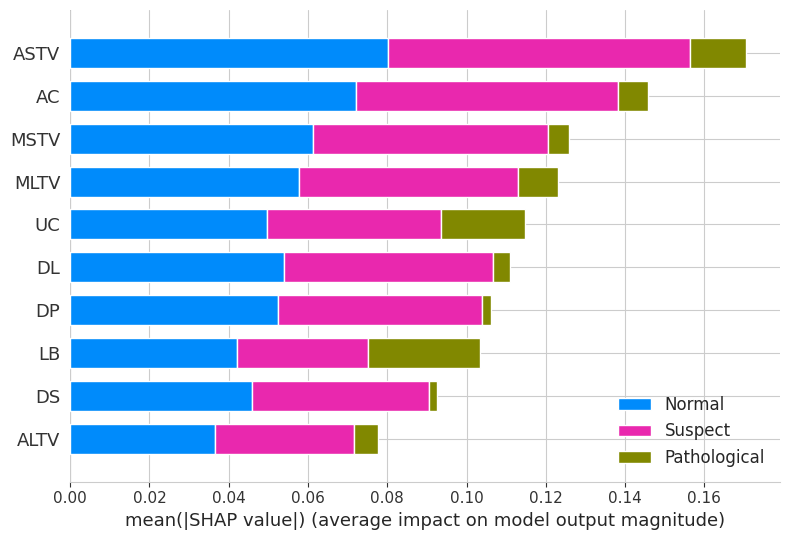

Figure saved: shap_summary_ctu_external_validation.png


In [9]:
import shap

scaler_full = StandardScaler().fit(X)
X_scaled_full = pd.DataFrame(scaler_full.transform(X), columns=FEATURES)

shap_model = XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0)
shap_model.fit(X_scaled_full, y - 1)

# Note: shap.TreeExplainer cannot parse this XGBoost version's multi-class
# base_score format (a known SHAP/XGBoost 3.x incompatibility -- confirmed by
# testing directly, not assumed). Using shap.explainers.Permutation instead,
# which treats the trained model as a black box via predict_proba -- this
# explains the exact same fitted model, just via a different, slower but
# fully compatible algorithm.
background = shap.sample(X_scaled_full, 50, random_state=42)
explainer = shap.explainers.Permutation(shap_model.predict_proba, background, seed=42)
shap_values = explainer(X_scaled_full)

print("SHAP values shape:", shap_values.values.shape)
shap_values_to_plot = [shap_values.values[:, :, i] for i in range(3)]

plt.figure()
shap.summary_plot(
    shap_values_to_plot,
    X_scaled_full,
    class_names=["Normal", "Suspect", "Pathological"],
    show=False
)
plt.tight_layout()
plt.savefig("../figures/shap_summary_ctu_external_validation.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved: shap_summary_ctu_external_validation.png")

In [10]:
mean_abs_shap = {
    cls: np.abs(shap_values_to_plot[i]).mean(axis=0)
    for i, cls in enumerate(["Normal", "Suspect", "Pathological"])
}
shap_importance = pd.DataFrame(mean_abs_shap, index=FEATURES)
shap_importance["Overall"] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values("Overall", ascending=False)
print("Mean |SHAP value| per feature, per class:")
shap_importance.round(4)

Mean |SHAP value| per feature, per class:


,Normal,Suspect,Pathological,Overall
ASTV,0.0802,0.0761,0.0143,0.0569
AC,0.0721,0.0662,0.0074,0.0486
MSTV,0.0612,0.0593,0.0053,0.0419
MLTV,0.0577,0.0552,0.0102,0.0410
UC,0.0497,0.0438,0.0211,0.0382
DL,0.0541,0.0526,0.0042,0.0370
DP,0.0525,0.0514,0.0024,0.0354
LB,0.0421,0.0330,0.0283,0.0345
DS,0.0459,0.0447,0.0019,0.0308
ALTV,0.0367,0.0349,0.0061,0.0259


## SHAP result — honest interpretation

ASTV, AC, and MSTV are the most influential features overall, consistent
with them being the strongest documented markers of fetal distress in the
primary source (ASTV and AC both directly tied to the FIGO consensus
definitions cited in `06_ctu_full_extraction.ipynb`) -- the model is
leaning on clinically sensible features, not arbitrary ones.

**The more useful finding is the Pathological column itself.** Mean |SHAP
value| for Pathological is 0.002-0.028 across every feature -- roughly
3-10x lower than the same features' influence on Normal/Suspect
predictions (0.03-0.08). LB is relatively the most influential feature for
Pathological specifically (0.0283), but even that is smaller than ASTV's
influence on Normal alone.

This is a direct, evidence-based explanation for the zero Pathological
recall reported above, not a new problem -- it shows *why* the fold results
and the SMOTE test came out the way they did: the model has not learned a
meaningful decision boundary for Pathological at all, for any feature. With
only 13 real examples, there is not enough signal for any feature to
consistently distinguish that class, regardless of which resampling
technique or feature is used. This corroborates the data-size-ceiling
conclusion from the SMOTE section using a completely different method,
rather than just restating it.

## Known Limitations

- **Pathological class is tiny (13 of 552 records)** -- even with 5-fold CV,
  each fold's test set has only 2-3 Pathological cases. Metrics involving
  that class (F1-Pathological, Pathological Recall) should be read as
  indicative, not precise -- a handful of cases flipping prediction shifts
  these numbers substantially. SMOTE was tried (see above) and moved recall off zero only marginally
  (1 of 13 total Pathological records caught, in a single fold) -- not a
  stable or repeatable gain. This confirms the class size is a genuine
  dataset-size constraint rather than a modelling or resampling choice
  that was simply left untried. SHAP corroborates this independently --
  every feature's influence on Pathological predictions is 3-10x weaker
  than its influence on Normal/Suspect, meaning the model has not learned
  a usable Pathological signal at all, regardless of technique.
- **10-feature set, not the original UCI 21/13.** By design (see
  `06_ctu_full_extraction.ipynb`) -- every feature here has a documented
  source, at the cost of leaving out several the original UCI model used.
- **Normal-class threshold (pH>=7.20)** carries the same weaker-anchored
  caveat noted in the extraction notebook -- it's a literature convention,
  not an official clinical standard, unlike the Pathological threshold.